In [1]:
import numpy as np
import matplotlib.pyplot as plt
import wandb
import pandas as pd

api = wandb.Api()

In [2]:
from matplotlib.ticker import MaxNLocator


def block_average(x, block_size):
    n = len(x) // block_size  # number of full blocks
    x_trim = x[: n * block_size]
    return x_trim.reshape(n, block_size).mean(axis=1)


def plot(adam, muon, title, ylabel, xlabel="Optimization Step", subsample=1, log=1, total_len=None):
    plt.figure(figsize=(10, 6))

    if total_len is None:
        total_len = len(adam)

    xrange = range(1, total_len + 1, subsample)

    if subsample > 1:
        adam = block_average(adam, subsample)
        muon = block_average(muon, subsample)

    plt.plot(xrange, adam, label="AdamW")
    plt.plot(xrange, muon, label="Muon")

    if log:
        plt.yscale("log")

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.legend()
    plt.show()

## BCAT - PDEArena NS cond - NAMO

In [3]:
run = api.run("schaefferlab1/ts/0363rmwj")
history1 = run.history(samples=100000)

adam_train = history1["train.data_loss"].dropna().values
adam_val = history1["val.l2_error"].dropna().values

In [4]:
run = api.run("schaefferlab1/ts/tenvqh2x")
history2 = run.history(samples=100000)

muon_train = history2["train.data_loss"].dropna().values
muon_val = history2["val.l2_error"].dropna().values

In [5]:
run = api.run("schaefferlab1/bcat_test/n50q2mh7")
history3 = run.history(samples=100000)

namo_train = history3["train.data_loss"].dropna().values
namo_val = history3["val.l2_error"].dropna().values

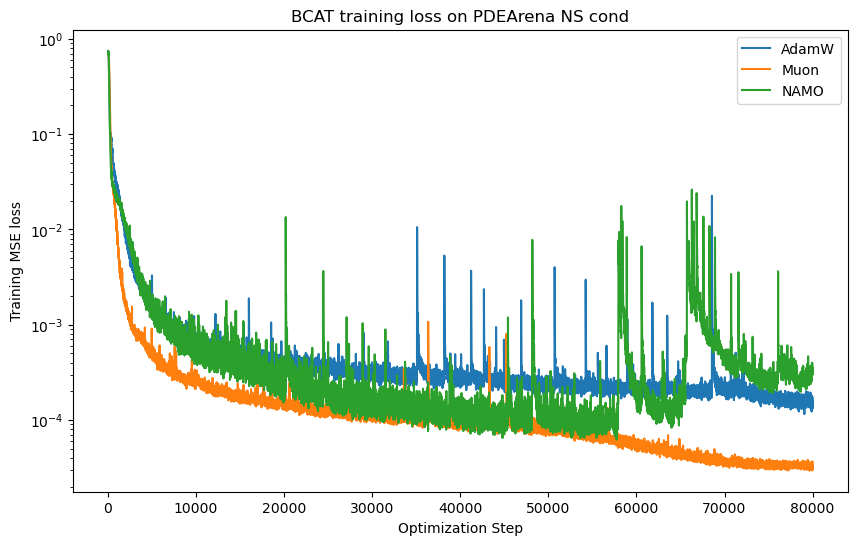

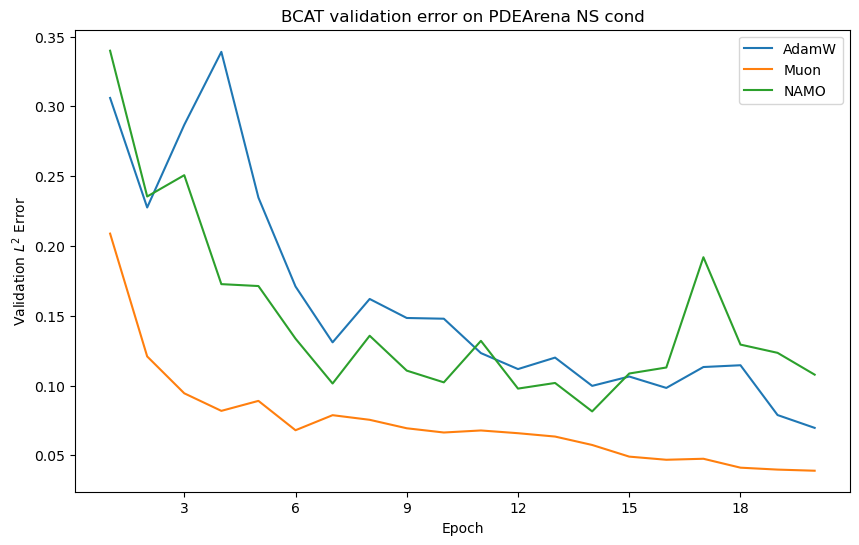

In [13]:
def plot_three(adam, muon, namo, title, ylabel, xlabel="Optimization Step", subsample=1, log=1, total_len=None):
    plt.figure(figsize=(10, 6))

    if total_len is None:
        total_len = len(adam)

    xrange = range(1, total_len + 1, subsample)

    if subsample > 1:
        adam = block_average(adam, subsample)
        muon = block_average(muon, subsample)
        namo = block_average(namo, subsample)
    plt.plot(xrange, adam, label="AdamW")
    plt.plot(xrange, muon, label="Muon")
    plt.plot(xrange, namo[:len(xrange)], label="NAMO")

    if log:
        plt.yscale("log")

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.legend()
    plt.show()

plot_three(adam_train, muon_train, namo_train, title="BCAT training loss on PDEArena NS cond", ylabel="Training MSE loss", subsample=5)
plot_three(
    adam_val,
    muon_val,
    namo_val,
    title="BCAT validation error on PDEArena NS cond",
    ylabel="Validation $L^2$ Error",
    xlabel="Epoch",
    log=0,
)

## BCAT - PDEArena NS cond

In [3]:
run = api.run("schaefferlab1/ts/0363rmwj")
history1 = run.history(samples=100000)

adam_train = history1["train.data_loss"].dropna().values
adam_val = history1["val.l2_error"].dropna().values

In [4]:
run = api.run("schaefferlab1/ts/tenvqh2x")
history2 = run.history(samples=100000)

muon_train = history2["train.data_loss"].dropna().values
muon_val = history2["val.l2_error"].dropna().values

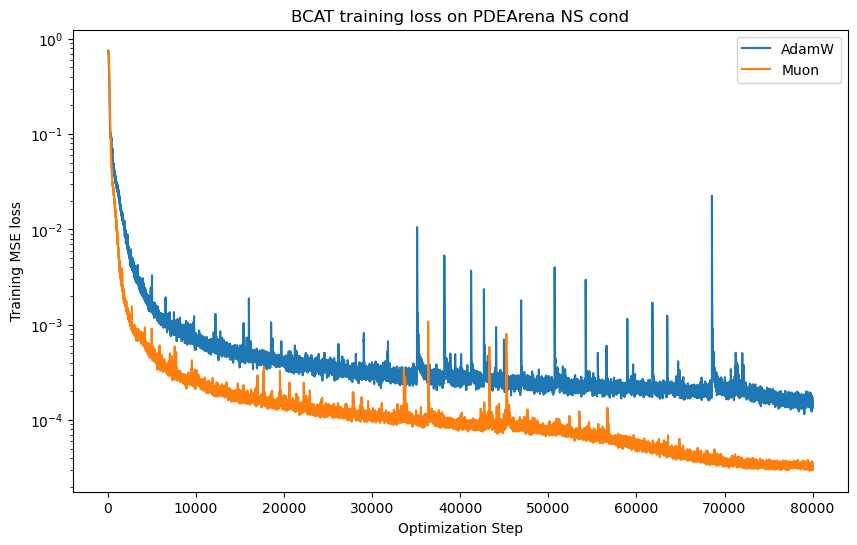

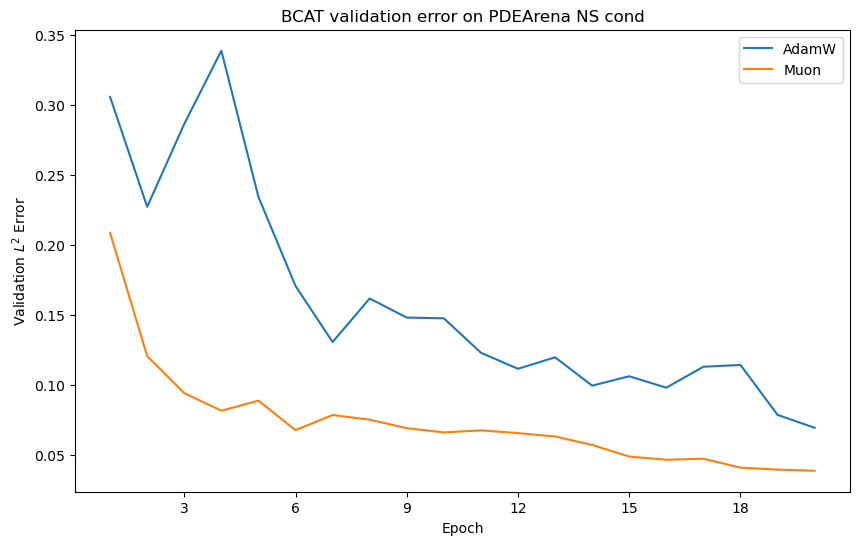

In [5]:
plot(adam_train, muon_train, title="BCAT training loss on PDEArena NS cond", ylabel="Training MSE loss", subsample=5)
plot(
    adam_val,
    muon_val,
    title="BCAT validation error on PDEArena NS cond",
    ylabel="Validation $L^2$ Error",
    xlabel="Epoch",
    log=0,
)

## BCAT - ALL

In [ ]:
api = wandb.Api(timeout=60)

run = api.run("schaefferlab1/fluids_test/u26ekkn1")
history3 = run.history(samples=200000)

adam_train = history3["train.data_loss"].dropna().values
adam_val = history3["val.l2_error"].dropna().values

In [ ]:
run = api.run("schaefferlab1/fluids_test/nesy9gh3")
history4 = run.history(samples=200000)

muon_train = history4["train.data_loss"].dropna().values
muon_val = history4["val.l2_error"].dropna().values

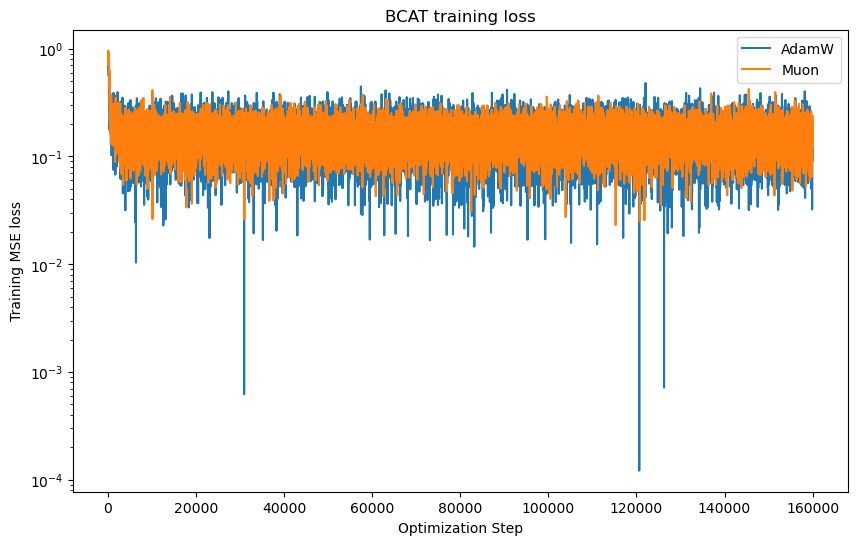

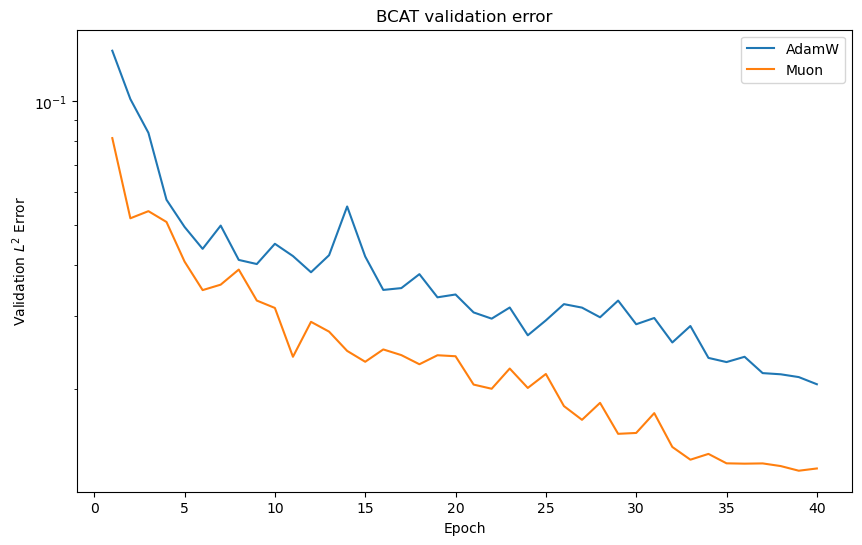

In [ ]:
plot(adam_train[:160000], muon_train, title="BCAT training loss", ylabel="Training MSE loss", subsample=10)
plot(adam_val, muon_val, title="BCAT validation error", ylabel="Validation $L^2$ Error", xlabel="Epoch", log=1)

## PROSE-FD - ALL

In [9]:
api = wandb.Api(timeout=60)

run = api.run("schaefferlab1/fluids_test/98oawabh")
history5 = run.history(samples=200000)

adam_train = history5["train.data_loss"].dropna().values
adam_val = history5["val.l2_error"].dropna().values

In [ ]:
# this will give error

# api = wandb.Api(timeout=120)

# run = api.run("schaefferlab1/prose_fd/iftr4ub6")
# history6 = run.history(samples=200000, keys=["_step", "train.data_loss", "val.l2_error", "train.step", "val.epoch"])

# muon_train = history6["train.data_loss"].dropna().values
# muon_val = history6["val.l2_error"].dropna().values

In [ ]:
import os

artifact = api.artifact("schaefferlab1/prose_fd/run-iftr4ub6-history:v2")
artifact_dir = artifact.download()

parquet_path = os.path.join(artifact_dir, "0000.parquet")
df = pd.read_parquet(parquet_path)

wandb:   1 of 1 files downloaded.  


In [ ]:
muon_train = df["train.data_loss"].dropna().values
muon_val = df["val.l2_error"].dropna().values

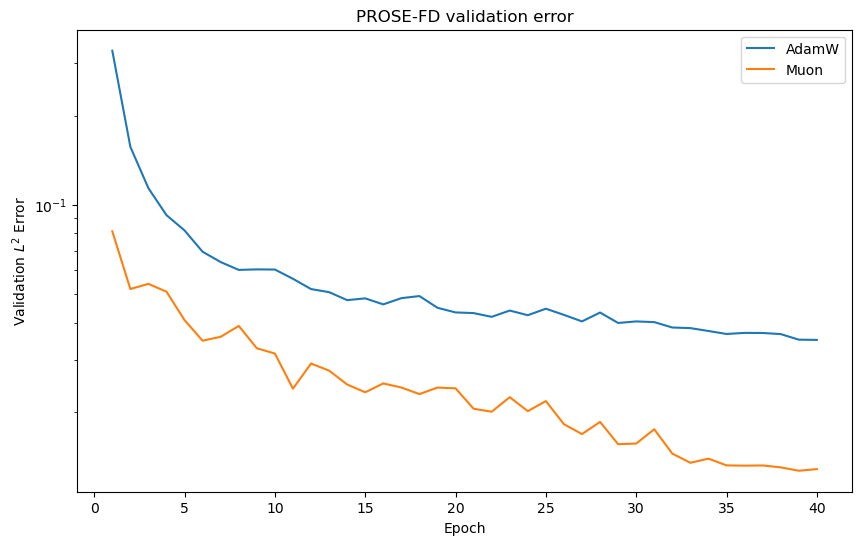

In [25]:
# plot(adam_train, muon_train, title="PROSE-FD training loss", ylabel="Training MSE loss", subsample=50)
plot(adam_val, muon_val, title="PROSE-FD validation error", ylabel="Validation $L^2$ Error", xlabel="Epoch", log=1)

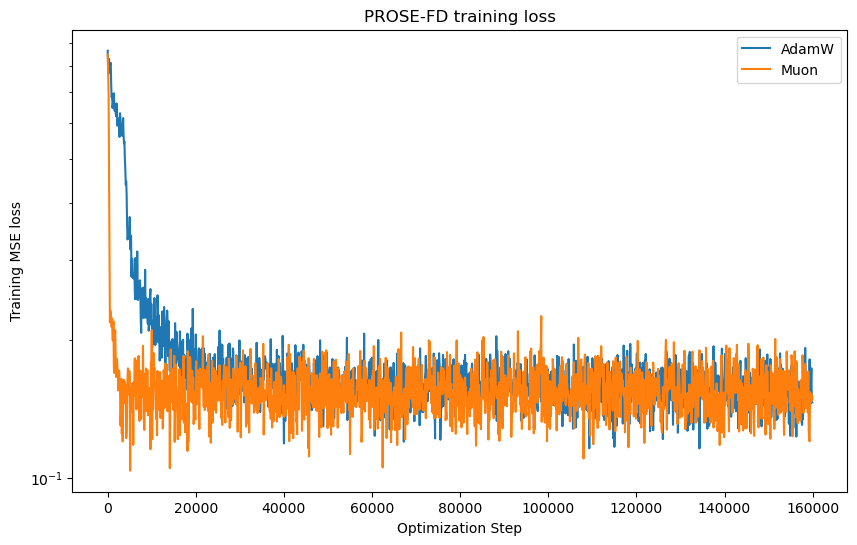

In [ ]:
def plot2(adam, muon, title, ylabel, xlabel="Optimization Step", subsample=1, log=1, total_len=None):
    plt.figure(figsize=(10, 6))

    if total_len is None:
        total_len = len(muon)

    xrange = range(1, total_len + 1, subsample)

    if subsample > 1:
        # adam = block_average(adam, subsample)
        muon = block_average(muon, subsample)

    plt.plot(xrange, adam, label="AdamW")
    plt.plot(xrange, muon, label="Muon")

    if log:
        plt.yscale("log")

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.legend()
    plt.show()


plot2(adam_train, muon_train, title="PROSE-FD training loss", ylabel="Training MSE loss", subsample=100)